<a href="https://colab.research.google.com/github/ChinmayPal1904/Internship-Tasks/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/content/data.csv", encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [9]:
print("Shape of dataset:", df.shape)
print("\nColumn Info:")
print(df.info())
print("\nSample Data:")
df.head()

Shape of dataset: (541909, 8)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

Sample Data:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [13]:
df = df.dropna()

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Sales']

print("\nData cleaned successfully!")



Data cleaned successfully!


In [37]:
def calculate_revenue(data):
    if 'Sales' in data.columns:
        return data['Sales']
    elif {'Quantity', 'UnitPrice'}.issubset(data.columns):
        return data['Quantity'] * data['UnitPrice']
    else:
        raise Exception("Revenue cannot be calculated: required columns missing")

revenue_series = calculate_revenue(df)

In [38]:
total_revenue = revenue_series.sum()
total_orders = df['InvoiceNo'].nunique()

print("\n--- BUSINESS KPIs ---")
print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)

if 'Profit' in df.columns:
    total_profit = df['Profit'].sum()
    print("Total Profit:", round(total_profit, 2))


--- BUSINESS KPIs ---
Total Revenue: 8300065.81
Total Orders: 22190


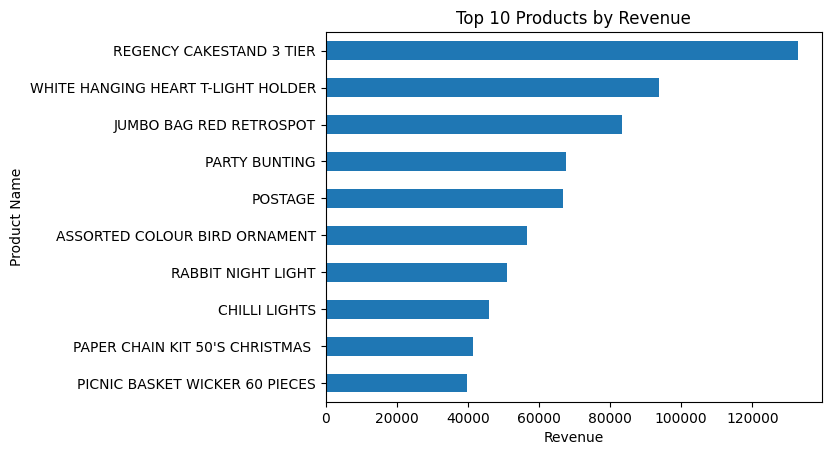

In [39]:
top_products = (
    df.assign(Revenue=revenue_series)
      .groupby('Description')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure()
top_products.sort_values().plot(kind='barh')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Name")
plt.show()

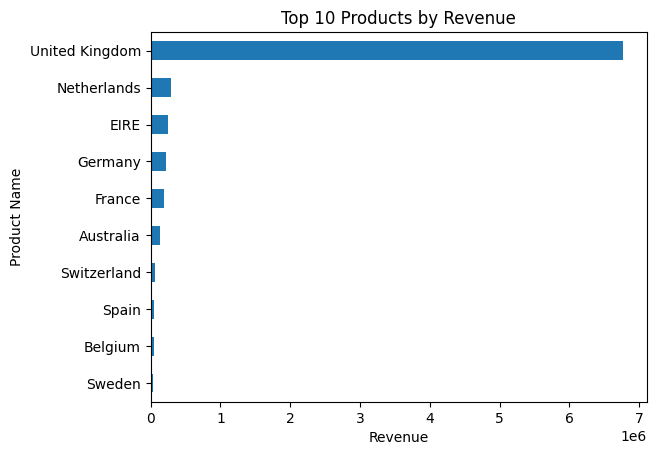

In [45]:
top_countries = (
    df.assign(Revenue=revenue_series)
      .groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure()
top_countries.sort_values().plot(kind='barh')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Name")
plt.show()

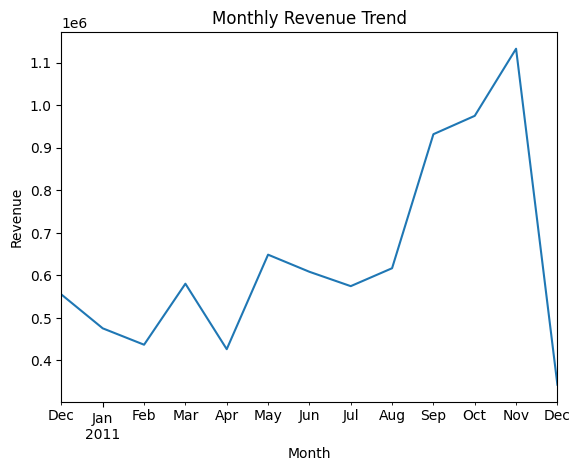

In [40]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = (
    df.assign(Revenue=revenue_series)
      .groupby('Month')['Revenue']
      .sum()
)

plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [41]:
if 'Region' in df.columns:
    region_revenue = (
        df.assign(Revenue=revenue_series)
          .groupby('Region')['Revenue']
          .sum()
    )

    plt.figure()
    region_revenue.plot(kind='bar')
    plt.title("Revenue by Region")
    plt.xlabel("Region")
    plt.ylabel("Revenue")
    plt.show()

In [42]:
if 'Category' in df.columns:
    category_revenue = (
        df.assign(Revenue=revenue_series)
          .groupby('Category')['Revenue']
          .sum()
    )

    plt.figure()
    category_revenue.plot(kind='pie', autopct='%1.1f%%')
    plt.title("Revenue Distribution by Category")
    plt.ylabel("")
    plt.show()

In [43]:
if 'Profit' in df.columns:
    profit_margin = (df['Profit'] / revenue_series) * 100
    print("\nAverage Profit Margin by Category:")
    print(profit_margin.groupby(df['Category']).mean())

In [44]:
print("\n--- KEY BUSINESS INSIGHTS ---")
print("1. A small set of products generates the majority of revenue.")
print("2. Revenue shows time-based trends and seasonality.")
print("3. Certain regions contribute more to business growth.")
print("4. High revenue does not always imply high profitability.")
print("5. Profit margin analysis helps identify risky categories.")

df.to_csv("cleaned_ecommerce_sales.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_ecommerce_sales.csv'")

print("\n✅ Business Sales Performance Analytics Completed Successfully!")


--- KEY BUSINESS INSIGHTS ---
1. A small set of products generates the majority of revenue.
2. Revenue shows time-based trends and seasonality.
3. Certain regions contribute more to business growth.
4. High revenue does not always imply high profitability.
5. Profit margin analysis helps identify risky categories.

Cleaned dataset saved as 'cleaned_ecommerce_sales.csv'

✅ Business Sales Performance Analytics Completed Successfully!
